# Appendix A2: Mobius Transformations

**Source span.** Pressley PDF pp. 390-398, Appendix 2 in the local source map. In this PDF copy, the extracted text starts on the Appendix 2 title page and runs through the final proposition about decomposing Mobius and conjugate-Mobius maps into reflections and inversions.

**Chapter goal.** Treat a Mobius transformation as a small projective machine on the extended complex plane: it is represented by a nonsingular 2 by 2 complex matrix, acts naturally on $C_\infty$, carries generalized circles to generalized circles, preserves angles when holomorphic, reverses orientation when conjugation is inserted, and supplies the transformations behind stereographic projection and the disk/half-plane models of hyperbolic geometry.

This notebook is original teaching material oriented by the assigned source pages. It does not use textbook figures, copied prose, exercise text, hints, or solutions.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from PIL import Image

START = Path.cwd().resolve()
candidates = [START, *START.parents]
workspace_child = START / "Elementary-Differential-Geometry-Andrew-Pressley"
if workspace_child.exists():
    candidates.append(workspace_child)

for candidate in candidates:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the Pressley book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact

UNIT = "appendix-a2"
UNIT_ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = UNIT_ARTIFACT_ROOT / "figures"
INTERACTIVE_DIR = UNIT_ARTIFACT_ROOT / "interactive"
CHECK_DIR = UNIT_ARTIFACT_ROOT / "checks"
TABLE_DIR = UNIT_ARTIFACT_ROOT / "tables"
for directory in (FIG_DIR, INTERACTIVE_DIR, CHECK_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

artifact_paths: list[Path] = []
numeric_checks: dict[str, float | int | bool | str] = {}
symbolic_checks: dict[str, bool | str] = {}

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})


def book_rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()


def remember(path: Path) -> Path:
    path = Path(path)
    if path not in artifact_paths:
        artifact_paths.append(path)
    return path


def clean_json(value):
    if isinstance(value, Path):
        return book_rel(value)
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, complex):
        return {"real": float(value.real), "imag": float(value.imag)}
    if isinstance(value, np.ndarray):
        return clean_json(value.tolist())
    if isinstance(value, dict):
        return {str(k): clean_json(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [clean_json(v) for v in value]
    return value


def write_json(path: Path, payload: dict) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(clean_json(payload), indent=2, sort_keys=True), encoding="utf-8")
    return remember(path)


def save_figure(fig, filename: str, *, dpi: int = 180) -> Path:
    path = FIG_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    return remember(path)


def save_plotly(fig: go.Figure, path: Path, *, height: int = 560) -> Path:
    fig.update_layout(height=height)
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return remember(path)


## Standalone Reading Guide

Mobius transformations are the appendix's compact language for the extended complex plane. A fractional linear map is controlled by a two-by-two complex matrix up to scale, and its natural home is the Riemann sphere rather than the ordinary plane alone. The notebook starts there so that infinity, inversions, and circle-line transformations are part of one visual model.

The main geometric invariant is generalized circles: ordinary circles and lines are treated as one family, and Mobius maps send that family to itself. The circle-line panel and the inversion panel show this with sampled point sets, while the symbolic checks verify that the transformation rules are not artifacts of the chosen drawing window. Cross-ratio invariance then gives the algebraic fingerprint behind the geometry; it is the quantity that survives every Mobius transformation.

The orientation and hyperbolic-model sections connect the appendix back to the course. Conjugation reverses orientation, while disk-preserving Mobius transformations act as isometries of the Poincare model used in the hyperbolic chapter. The applied lab classifies image sets and residuals so the reader can test a transformation as a geometric object rather than just evaluate a formula.


## Computational Translation Guide And Route

| Pressley idea | Computational object in this notebook | What to inspect |
| --- | --- | --- |
| Extended complex plane $C_\infty$ | finite complex numbers plus the north-pole limit under stereographic projection | infinity is not a large complex number; it is the missing point that compactifies the plane |
| Mobius map $(az+b)/(cz+d)$ | a nonsingular matrix, up to nonzero scalar multiple | scaling the matrix does not change the map, and the inverse matrix gives the inverse transformation |
| Straight lines and circles as one class | real equation $A|z|^2+\bar Bz+B\bar z+C=0$ | reciprocal maps swap the roles of some circles and lines |
| Conformality and conjugation | local tangent frames, signed area, and symbolic metric checks | holomorphic maps preserve oriented angles; conjugate-Mobius maps preserve angles but reverse orientation |
| Inversion in a circle | $a+r^2/(\bar z-\bar a)$ | distance products, orthogonal circles, and setwise preservation are directly checkable |
| Cross-ratio | exact SymPy identity and numeric point experiment | the same four-point projective invariant survives every Mobius map |
| Stereographic and hyperbolic links | Riemann-sphere view and disk automorphism checks | Mobius maps are the transition language for conformal sphere charts and hyperbolic models |

The route is visual first: build the compactified plane, watch matrix generators act on a grid, test Circle preservation, isolate inversion, verify cross-ratio invariance, compare orientation behavior, then use the same machinery in the disk model.

In [2]:
source_span = {
    "unit": "Appendix A2",
    "pdf_pages": "390-398",
    "printed_pages_seen_in_extraction": "Appendix 2 title page through printed page 399 in this PDF copy",
    "source_map_note": "AGENTS.md maps Appendices A0-A2 to PDF pages 379-398; this pass uses the assigned Appendix A2 span only.",
    "orientation_only": True,
}

storyboard = {
    "chapter_goal": "Understand Mobius and conjugate-Mobius transformations as projective maps of the extended complex plane that preserve generalized circles and conformal angle data.",
    "source_span_read": source_span,
    "library_routing_table": [
        {"concept": "extended complex plane and stereographic link", "representation": "rotatable Riemann-sphere chart", "library": "Plotly", "why": "3D interaction exposes infinity as a compactifying point"},
        {"concept": "Mobius generators and matrix action", "representation": "interactive transformed complex grid", "library": "Plotly + NumPy", "why": "dropdown comparison shows translations, dilations, reciprocal maps, and a full fractional-linear map"},
        {"concept": "Circle/line preservation", "representation": "source-image curve pairs with fitted generalized-circle equations", "library": "Matplotlib + NumPy", "why": "durable static proof visual plus numeric residuals"},
        {"concept": "inversion", "representation": "orthogonal-circle diagram and distance-product checks", "library": "Matplotlib + NumPy", "why": "the defining metric relation and setwise invariant are directly visible"},
        {"concept": "cross-ratio", "representation": "four-point before/after diagram and exact symbolic identity", "library": "Matplotlib + SymPy", "why": "projective invariant should be exact, not just sampled"},
        {"concept": "orientation and conjugation", "representation": "local tangent triangle with signed area checks", "library": "Matplotlib + SymPy", "why": "angle preservation and orientation reversal are local differential facts"},
        {"concept": "hyperbolic-model link", "representation": "Poincare disk geodesics before/after a disk automorphism", "library": "Matplotlib + NumPy", "why": "Appendix A2 supplies the transformations used in Chapter 11"},
    ],
    "visual_sequence": [
        {"concept": "extended complex plane", "artifact": "interactive/extended-plane-stereographic-link.html", "check": "stereographic points have unit norm and large radii approach the north pole"},
        {"concept": "Mobius grid action", "artifact": "interactive/mobius-generator-gallery.html", "check": "matrix scaling, inverse, and local conformality residuals"},
        {"concept": "Circle preservation", "artifact": "figures/circle-line-preservation.png", "check": "transformed curves fit generalized-circle equations"},
        {"concept": "inversion", "artifact": "figures/inversion-orthogonal-circle.png", "check": "distance product and orthogonal-circle setwise residuals"},
        {"concept": "cross-ratio", "artifact": "figures/cross-ratio-invariance.png", "check": "exact SymPy invariant and numeric residual"},
        {"concept": "orientation/conjugation", "artifact": "figures/orientation-conjugation.png", "check": "direct signed area positive and conjugate signed area negative"},
        {"concept": "hyperbolic disk link", "artifact": "figures/hyperbolic-disk-mobius-link.png", "check": "disk automorphism preserves boundary and hyperbolic distance"},
    ],
    "applied_lab": "Classify the images of editable generalized circles under a chosen Mobius map and check the pole-through-Circle rule.",
}

source_path = write_json(CHECK_DIR / "source-span.json", source_span)
storyboard_path = write_json(CHECK_DIR / "visual-storyboard.json", storyboard)
pd.DataFrame(storyboard["library_routing_table"])


,concept,representation,library,why
0,extended complex plane and stereographic link,rotatable Riemann-sphere chart,Plotly,3D interaction exposes infinity as a compactif...
1,Mobius generators and matrix action,interactive transformed complex grid,Plotly + NumPy,"dropdown comparison shows translations, dilati..."
2,Circle/line preservation,source-image curve pairs with fitted generaliz...,Matplotlib + NumPy,durable static proof visual plus numeric resid...
3,inversion,orthogonal-circle diagram and distance-product...,Matplotlib + NumPy,the defining metric relation and setwise invar...
4,cross-ratio,four-point before/after diagram and exact symb...,Matplotlib + SymPy,"projective invariant should be exact, not just..."
5,orientation and conjugation,local tangent triangle with signed area checks,Matplotlib + SymPy,angle preservation and orientation reversal ar...
6,hyperbolic-model link,Poincare disk geodesics before/after a disk au...,Matplotlib + NumPy,Appendix A2 supplies the transformations used ...


## Complex-Plane Helper Functions

The helpers below keep the mathematics visible: a Mobius map is stored as `(a,b,c,d)`, a generalized Circle is fitted by the real equation

$$A(x^2+y^2)+2px+2qy+C=0,$$

and exact identities are handled separately by SymPy rather than hidden inside plotting code.

In [3]:
EPS = 1e-12


def mobius_array(z, M):
    a, b, c, d = M
    z = np.asarray(z, dtype=np.complex128)
    denom = c * z + d
    out = np.full(z.shape, np.nan + 1j * np.nan, dtype=np.complex128)
    mask = np.abs(denom) > EPS
    out[mask] = (a * z[mask] + b) / denom[mask]
    return out


def mobius_derivative(z: complex, M) -> complex:
    a, b, c, d = M
    return (a * d - b * c) / (c * z + d) ** 2


def inverse_matrix(M):
    a, b, c, d = M
    return (d, -b, -c, a)


def split_segments(points, *, max_abs=8.0):
    points = np.asarray(points, dtype=np.complex128)
    good = np.isfinite(points.real) & np.isfinite(points.imag) & (np.abs(points) <= max_abs)
    segments = []
    start = None
    for idx, ok in enumerate(good):
        if ok and start is None:
            start = idx
        if (not ok or idx == len(good) - 1) and start is not None:
            end = idx if not ok else idx + 1
            if end - start >= 2:
                segments.append(points[start:end])
            start = None
    return segments


def circle_points(center: complex, radius: float, n: int = 500, *, endpoint: bool = True):
    theta = np.linspace(0, 2 * np.pi, n, endpoint=endpoint)
    return center + radius * np.exp(1j * theta)


def line_points(point: complex, direction: complex, tmin=-2.5, tmax=2.5, n=500):
    t = np.linspace(tmin, tmax, n)
    return point + t * direction


def fit_generalized_circle(points):
    points = np.asarray(points, dtype=np.complex128)
    points = points[np.isfinite(points.real) & np.isfinite(points.imag)]
    x = points.real
    y = points.imag
    A = np.column_stack([x * x + y * y, 2 * x, 2 * y, np.ones_like(x)])
    _, _, vh = np.linalg.svd(A, full_matrices=False)
    coeff = vh[-1]
    coeff = coeff / np.linalg.norm(coeff)
    residuals = A @ coeff
    return coeff, float(np.sqrt(np.mean(residuals**2)))


def classify_generalized_circle(coeff, tol=1e-5):
    A, p, q, C = coeff
    if abs(A) < tol:
        return "line"
    radius_sq = (p * p + q * q) / (A * A) - C / A
    if radius_sq > tol:
        return "circle"
    return "degenerate"


def plot_complex_curve(ax, points, **kwargs):
    points = np.asarray(points, dtype=np.complex128)
    return ax.plot(points.real, points.imag, **kwargs)


def format_complex_axes(ax, *, title: str, xlim=(-3, 3), ylim=(-3, 3)):
    ax.axhline(0, color="#777777", lw=0.8, alpha=0.65)
    ax.axvline(0, color="#777777", lw=0.8, alpha=0.65)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Re z")
    ax.set_ylabel("Im z")
    ax.set_title(title)
    ax.grid(True, alpha=0.18)


def signed_area(points):
    points = np.asarray(points, dtype=np.complex128)
    x = points.real
    y = points.imag
    return 0.5 * float(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def angle_between(u: complex, v: complex) -> float:
    dot = u.real * v.real + u.imag * v.imag
    norm = abs(u) * abs(v)
    return float(np.arccos(np.clip(dot / norm, -1.0, 1.0)))


def cross_ratio(z1, z2, z3, z4):
    return ((z1 - z3) * (z2 - z4)) / ((z1 - z4) * (z2 - z3))


def inversion(z, center=0 + 0j, radius=1.0):
    z = np.asarray(z, dtype=np.complex128)
    return center + radius**2 / (np.conj(z) - np.conj(center))


def stereographic_to_sphere(z):
    z = np.asarray(z, dtype=np.complex128)
    r2 = z.real**2 + z.imag**2
    denom = 1 + r2
    return np.column_stack([2 * z.real / denom, 2 * z.imag / denom, (r2 - 1) / denom])


def disk_auto(z, a):
    z = np.asarray(z, dtype=np.complex128)
    return (z - a) / (1 - np.conj(a) * z)


def hyp_dist_disk(z, w):
    z = complex(z)
    w = complex(w)
    arg = 1 + 2 * abs(z - w) ** 2 / ((1 - abs(z) ** 2) * (1 - abs(w) ** 2))
    return float(np.arccosh(max(1.0, arg)))


def disk_geodesic_points(z, w, n=350):
    z = complex(z)
    w = complex(w)
    if abs(np.imag(np.conj(z) * w)) < 1e-10:
        return np.linspace(z, w, n)
    A = 2 * np.array([[z.real, z.imag], [w.real, w.imag]], dtype=float)
    rhs = np.array([abs(z) ** 2 + 1, abs(w) ** 2 + 1], dtype=float)
    center_xy = np.linalg.solve(A, rhs)
    center = center_xy[0] + 1j * center_xy[1]
    radius = np.sqrt(max(0.0, abs(center) ** 2 - 1))
    theta1 = np.angle(z - center)
    theta2 = np.angle(w - center)
    delta = (theta2 - theta1 + np.pi) % (2 * np.pi) - np.pi
    deltas = [delta, delta - 2 * np.pi if delta > 0 else delta + 2 * np.pi]
    candidates = [center + radius * np.exp(1j * (theta1 + np.linspace(0, d, n))) for d in deltas]
    return min(candidates, key=lambda pts: (np.max(np.abs(pts)), np.mean(np.abs(pts))))


## Extended Complex Plane: Infinity As A Chart Point

The extended plane $C_\infty$ is best treated computationally as a projective line rather than as a plane with a very large coordinate. Stereographic projection makes this precise: finite complex numbers land on the sphere, while sequences with $|z|\to\infty$ approach the north pole. This is the geometric reason a fractional-linear formula can send one finite pole to infinity and send infinity to a finite value.

In [4]:
theta = np.linspace(0, 2 * np.pi, 80)
phi = np.linspace(0, np.pi, 40)
Theta, Phi = np.meshgrid(theta, phi)
X = np.sin(Phi) * np.cos(Theta)
Y = np.sin(Phi) * np.sin(Theta)
Z = np.cos(Phi)

sample_z = np.array([0 + 0j, 1 + 0j, 1j, -1 + 0.5j, 2 - 1j], dtype=np.complex128)
sphere_pts = stereographic_to_sphere(sample_z)
norms = np.linalg.norm(sphere_pts, axis=1)
numeric_checks["stereographic_unit_norm_residual"] = float(np.max(np.abs(norms - 1)))
large_heights = stereographic_to_sphere(np.array([10**k + 0j for k in range(1, 6)], dtype=np.complex128))[:, 2]
numeric_checks["stereographic_large_radius_to_north_pole_residual"] = float(abs(1 - large_heights[-1]))

fig = go.Figure()
fig.add_surface(x=X, y=Y, z=Z, colorscale="Blues", opacity=0.52, showscale=False, hoverinfo="skip")
fig.add_trace(go.Scatter3d(
    x=sphere_pts[:, 0], y=sphere_pts[:, 1], z=sphere_pts[:, 2],
    mode="markers+text", marker={"size": 6, "color": "#b2182b"},
    text=["0", "1", "i", "-1+0.5i", "2-i"], textposition="top center",
    name="finite complex points",
))
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[1], mode="markers+text",
    marker={"size": 8, "color": "#111111"}, text=["infinity"], textposition="top center",
    name="north pole",
))
for R in [1, 2, 5, 20]:
    circle = R * np.exp(1j * theta)
    pts = stereographic_to_sphere(circle)
    fig.add_trace(go.Scatter3d(x=pts[:, 0], y=pts[:, 1], z=pts[:, 2], mode="lines", line={"width": 3}, name=f"|z|={R}"))
fig.update_layout(
    title="Extended complex plane via stereographic projection",
    scene={"aspectmode": "data", "xaxis_title": "X", "yaxis_title": "Y", "zaxis_title": "Z"},
    margin={"l": 0, "r": 0, "t": 45, "b": 0},
)
path = save_plotly(fig, INTERACTIVE_DIR / "extended-plane-stereographic-link.html", height=620)
display_artifact(path, width="100%", height=620)


## Mobius Maps As Matrix Actions

A Mobius transformation is represented by a matrix

$$\begin{pmatrix}a&b\\c&d\end{pmatrix}, \qquad ad-bc\ne 0,$$

with scalar multiples representing the same map. The dropdown artifact compares the three generator types from the appendix and a full fractional-linear map. Look for the two behaviors that do not happen under affine maps: a pole is removed from the finite chart, and reciprocal action bends some lines into circles.

In [5]:
def grid_lines(limit=2.2, levels=None, n=260):
    if levels is None:
        levels = np.linspace(-2, 2, 9)
    t = np.linspace(-limit, limit, n)
    lines = []
    for value in levels:
        lines.append((t + 1j * value, "horizontal"))
        lines.append((value + 1j * t, "vertical"))
    return lines


transformations = [
    ("identity", (1 + 0j, 0 + 0j, 0 + 0j, 1 + 0j)),
    ("translation z+a", (1 + 0j, 0.75 + 0.45j, 0 + 0j, 1 + 0j)),
    ("complex dilation az", (0.82 * np.exp(0.55j), 0 + 0j, 0 + 0j, 1 + 0j)),
    ("reciprocal 1/z", (0 + 0j, 1 + 0j, 1 + 0j, 0 + 0j)),
    ("full Mobius", (0.72 + 0.38j, -0.55 + 0.42j, 0.20 - 0.16j, 1.0 + 0.08j)),
]

fig = go.Figure()
groups: dict[str, list[int]] = {}
lines = grid_lines()
for group_idx, (name, M) in enumerate(transformations):
    groups[name] = []
    for line, orientation in lines:
        image = mobius_array(line, M)
        for segment in split_segments(image, max_abs=5.5):
            color = "#2b6cb0" if orientation == "horizontal" else "#c2410c"
            fig.add_trace(go.Scatter(
                x=segment.real, y=segment.imag, mode="lines",
                line={"color": color, "width": 1.25},
                opacity=0.82, showlegend=False, visible=(group_idx == 0),
                hoverinfo="skip",
            ))
            groups[name].append(len(fig.data) - 1)

buttons = []
for name, _ in transformations:
    visible = [False] * len(fig.data)
    for idx in groups[name]:
        visible[idx] = True
    buttons.append({
        "label": name,
        "method": "update",
        "args": [{"visible": visible}, {"title": f"Complex grid under {name}"}],
    })

fig.update_layout(
    title="Complex grid under identity",
    updatemenus=[{"type": "dropdown", "x": 0.02, "y": 1.12, "buttons": buttons}],
    xaxis={"scaleanchor": "y", "range": [-5.5, 5.5], "zeroline": True, "title": "Re w"},
    yaxis={"range": [-5.5, 5.5], "zeroline": True, "title": "Im w"},
    margin={"l": 45, "r": 20, "t": 70, "b": 45},
)
path = save_plotly(fig, INTERACTIVE_DIR / "mobius-generator-gallery.html", height=620)

M_full = transformations[-1][1]
sample = np.array([-1.1 + 0.4j, -0.25 + 0.85j, 0.55 - 0.2j, 1.25 + 0.7j], dtype=np.complex128)
scaled = tuple((2.5 - 1.2j) * value for value in M_full)
numeric_checks["mobius_matrix_scale_residual"] = float(np.max(np.abs(mobius_array(sample, M_full) - mobius_array(sample, scaled))))
numeric_checks["mobius_inverse_residual"] = float(np.max(np.abs(mobius_array(mobius_array(sample, M_full), inverse_matrix(M_full)) - sample)))
z0 = 0.18 + 0.37j
D = mobius_derivative(z0, M_full)
numeric_checks["mobius_conformal_angle_residual"] = abs(angle_between(D, 1j * D) - np.pi / 2)
numeric_checks["mobius_conformal_scale_residual"] = abs(abs(D) - abs(1j * D))

display_artifact(path, width="100%", height=620)


## Why Lines And Circles Belong To One Class

A capital-C **Circle** here means either an ordinary circle or a straight line. The unified equation $A|z|^2+\bar Bz+B\bar z+C=0$ is useful because the reciprocal map $z\mapsto 1/z$ simply exchanges the leading and constant roles after clearing denominators. The next figure uses a translated reciprocal map so the pole is visible away from the origin. Curves through the pole become lines; curves missing the pole become ordinary circles.

C:\Users\rahul\AppData\Local\Temp\ipykernel_31384\2213820903.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", fontsize=8)


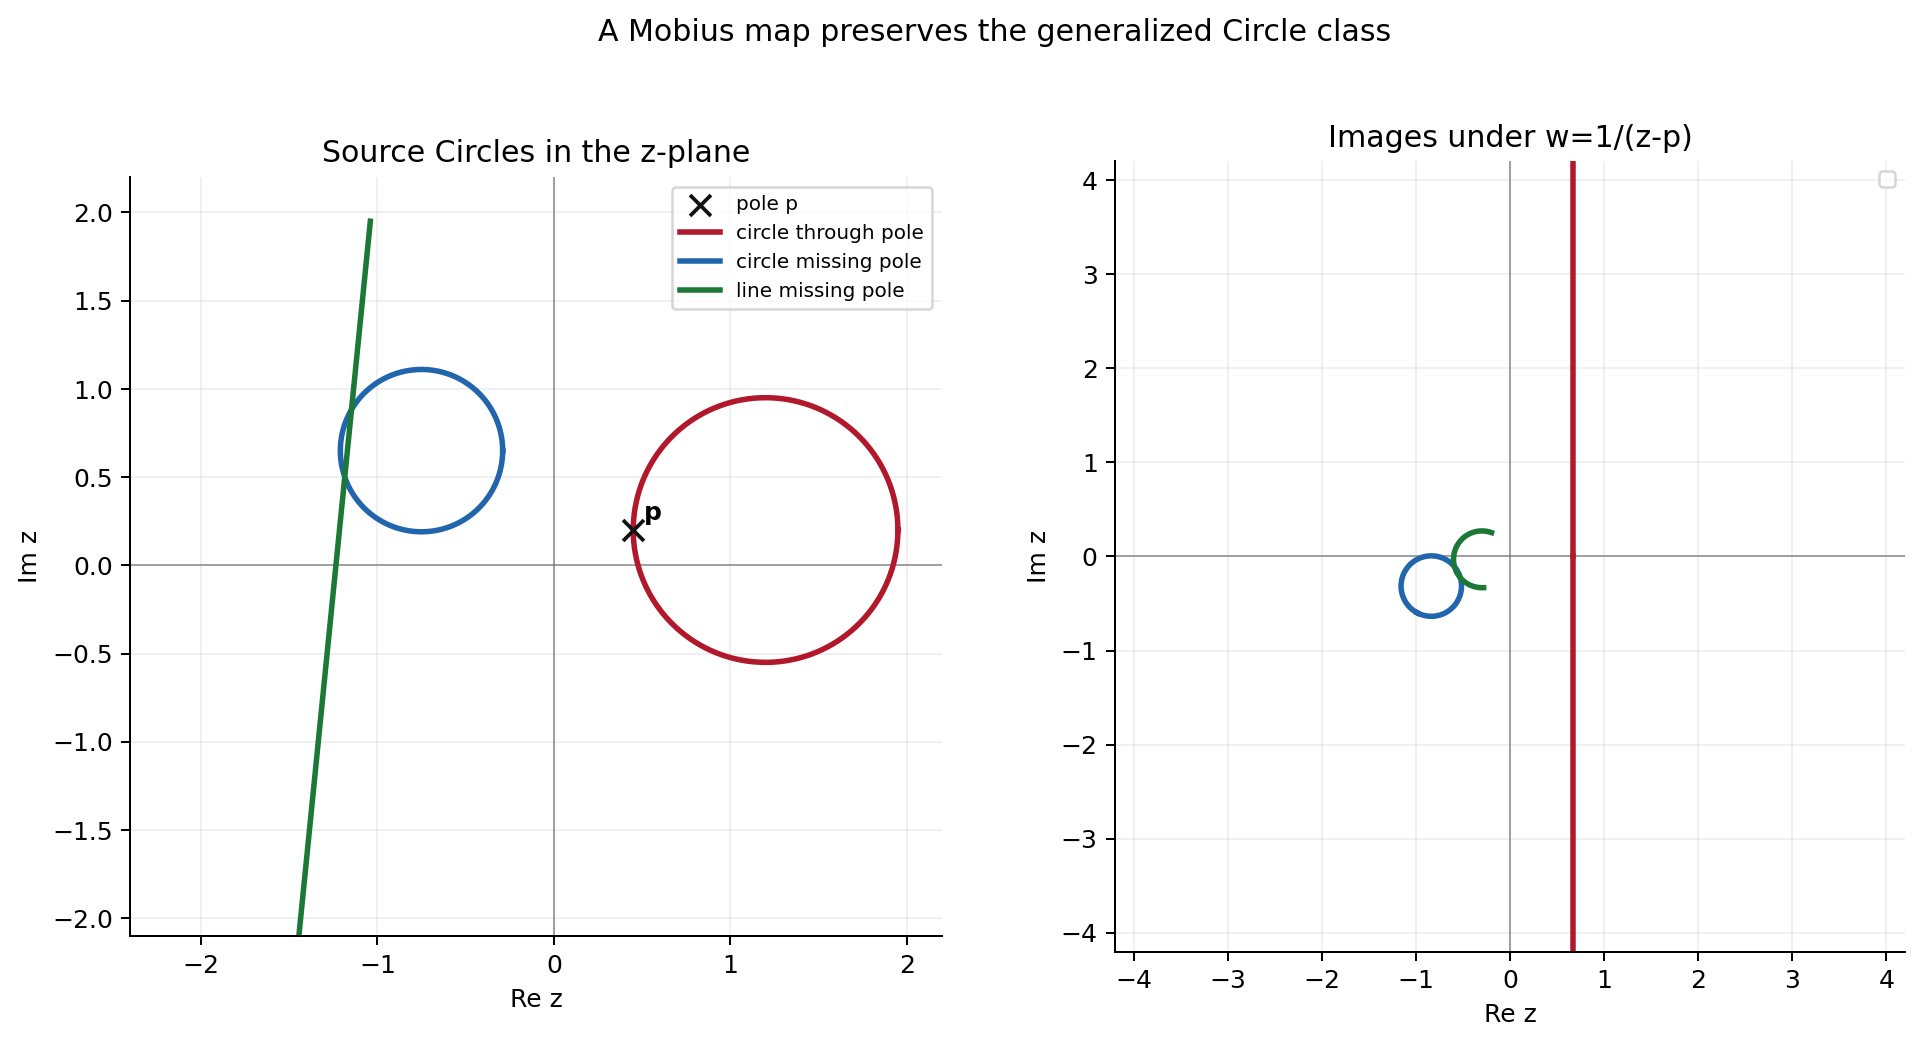

,source,image_classification,fit_rms,leading_coefficient_abs
0,circle through pole,line,1.427902e-15,7.463919e-17
1,circle missing pole,circle,5.967931e-16,6.607300e-01
2,line missing pole,circle,4.797381e-17,9.573512e-01


In [6]:
u, v, Acoef, pcoef, qcoef, Ccoef = sp.symbols("u v A p q C", real=True)
den = u**2 + v**2
x_expr = u / den
y_expr = -v / den
circle_expr = Acoef * (x_expr**2 + y_expr**2) + 2 * pcoef * x_expr + 2 * qcoef * y_expr + Ccoef
reciprocal_expr = sp.factor(den * circle_expr)
expected_expr = Ccoef * den + 2 * pcoef * u - 2 * qcoef * v + Acoef
symbolic_checks["reciprocal_circle_line_coefficient_swap"] = bool(sp.simplify(reciprocal_expr - expected_expr) == 0)

pole = 0.45 + 0.20j
M_pole = (0 + 0j, 1 + 0j, 1 + 0j, -pole)  # w = 1/(z-pole)
source_curves = {
    "circle through pole": circle_points(pole + 0.75, 0.75, n=720),
    "circle missing pole": circle_points(-0.75 + 0.65j, 0.46, n=720),
    "line missing pole": line_points(-1.25 - 0.15j, 0.1 + 1j, -2.1, 2.1, n=720),
}
colors = {
    "circle through pole": "#b2182b",
    "circle missing pole": "#2166ac",
    "line missing pole": "#1b7837",
}

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.7))
format_complex_axes(axes[0], title="Source Circles in the z-plane", xlim=(-2.4, 2.2), ylim=(-2.1, 2.2))
format_complex_axes(axes[1], title="Images under w=1/(z-p)", xlim=(-4.2, 4.2), ylim=(-4.2, 4.2))
axes[0].scatter([pole.real], [pole.imag], s=70, color="#111111", marker="x", zorder=5, label="pole p")
axes[0].text(pole.real + 0.06, pole.imag + 0.06, "p", weight="bold")

circle_records = []
for name, pts in source_curves.items():
    plot_complex_curve(axes[0], pts, color=colors[name], lw=2.2, label=name)
    image = mobius_array(pts, M_pole)
    for segment in split_segments(image, max_abs=9):
        plot_complex_curve(axes[1], segment, color=colors[name], lw=2.2)
    finite = image[np.isfinite(image.real) & np.isfinite(image.imag) & (np.abs(image) < 20)]
    coeff, rms = fit_generalized_circle(finite)
    classification = classify_generalized_circle(coeff)
    circle_records.append({
        "source": name,
        "image_classification": classification,
        "fit_rms": rms,
        "leading_coefficient_abs": abs(coeff[0]),
    })

for ax in axes:
    ax.legend(loc="upper right", fontsize=8)
fig.suptitle("A Mobius map preserves the generalized Circle class", y=1.02)
path = save_figure(fig, "circle-line-preservation.png")
display_artifact(path, width=980)

circle_table = pd.DataFrame(circle_records)
numeric_checks["circle_line_max_fit_residual"] = float(circle_table["fit_rms"].max())
numeric_checks["circle_through_pole_image_leading_abs"] = float(circle_table.loc[circle_table["source"] == "circle through pole", "leading_coefficient_abs"].iloc[0])
circle_table


## Inversion: The Circle Version Of Reflection

The inversion in a circle with center $a$ and radius $r$ sends $z$ to $a+r^2/(\bar z-\bar a)$. It is conjugate-Mobius, so it preserves angles but reverses orientation. The defining metric check is $|z-a|\,|I(z)-a|=r^2$. A second, more geometric check is Pressley's orthogonality criterion: a circle is fixed setwise by the inversion exactly when it meets the inversion circle at right angles.

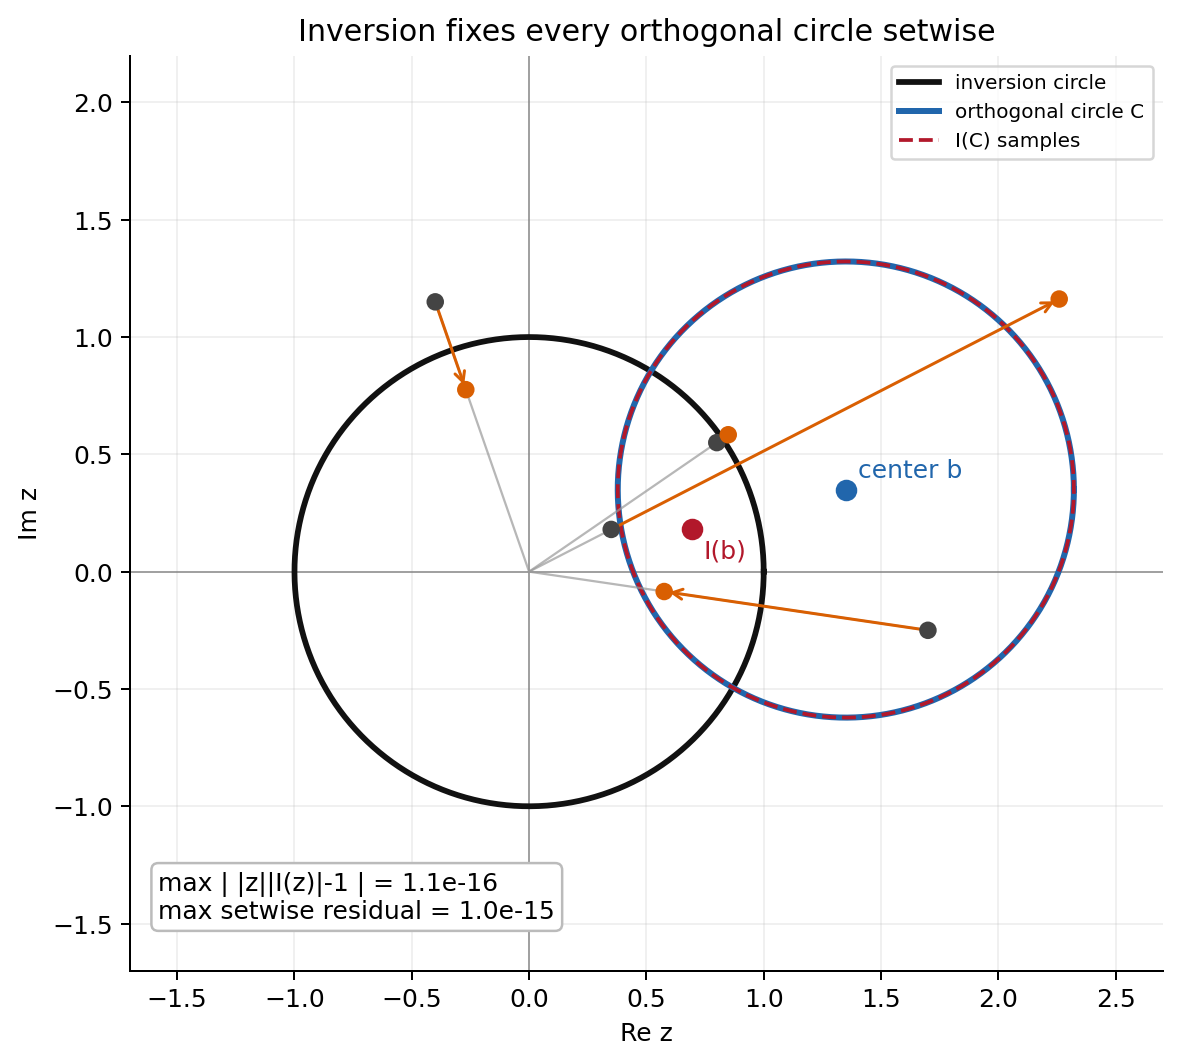

In [7]:
a_inv = 0 + 0j
r_inv = 1.0
b_center = 1.35 + 0.35j
s_radius = np.sqrt(abs(b_center - a_inv) ** 2 - r_inv**2)
orth_circle = circle_points(b_center, s_radius, n=720)
orth_image = inversion(orth_circle, a_inv, r_inv)

sample_ray_points = np.array([0.35 + 0.18j, 0.8 + 0.55j, -0.4 + 1.15j, 1.7 - 0.25j], dtype=np.complex128)
sample_images = inversion(sample_ray_points, a_inv, r_inv)
product_residual = np.abs(np.abs(sample_ray_points - a_inv) * np.abs(sample_images - a_inv) - r_inv**2)
setwise_residual = np.abs(np.abs(orth_image - b_center) - s_radius)
orthogonality_residual = abs(abs(b_center - a_inv) ** 2 - (r_inv**2 + s_radius**2))
center_image = complex(inversion(np.array([b_center]), a_inv, r_inv)[0])

numeric_checks["inversion_distance_product_residual"] = float(product_residual.max())
numeric_checks["inversion_setwise_circle_residual"] = float(setwise_residual.max())
numeric_checks["inversion_orthogonality_residual"] = float(orthogonality_residual)
numeric_checks["inversion_center_image_inside_fixed_circle"] = bool(abs(center_image - b_center) < s_radius)

fig, ax = plt.subplots(figsize=(7.4, 7.1))
format_complex_axes(ax, title="Inversion fixes every orthogonal circle setwise", xlim=(-1.7, 2.7), ylim=(-1.7, 2.2))
plot_complex_curve(ax, circle_points(a_inv, r_inv, n=720), color="#111111", lw=2.3, label="inversion circle")
plot_complex_curve(ax, orth_circle, color="#2166ac", lw=2.4, label="orthogonal circle C")
plot_complex_curve(ax, orth_image, color="#b2182b", lw=1.5, ls="--", label="I(C) samples")
ax.scatter([b_center.real], [b_center.imag], s=58, color="#2166ac", zorder=4)
ax.scatter([center_image.real], [center_image.imag], s=58, color="#b2182b", zorder=4)
ax.text(b_center.real + 0.05, b_center.imag + 0.05, "center b", color="#2166ac")
ax.text(center_image.real + 0.05, center_image.imag - 0.12, "I(b)", color="#b2182b")
for z, w in zip(sample_ray_points, sample_images):
    ax.plot([0, z.real], [0, z.imag], color="#999999", lw=0.9, alpha=0.7)
    ax.scatter([z.real, w.real], [z.imag, w.imag], s=[36, 36], color=["#444444", "#d95f02"], zorder=5)
    ax.annotate("", xy=(w.real, w.imag), xytext=(z.real, z.imag), arrowprops={"arrowstyle": "->", "color": "#d95f02", "lw": 1.2})
ax.text(-1.58, -1.48, f"max | |z||I(z)|-1 | = {product_residual.max():.1e}\nmax setwise residual = {setwise_residual.max():.1e}", bbox={"boxstyle": "round,pad=0.28", "fc": "white", "ec": "#bbbbbb"})
ax.legend(loc="upper right", fontsize=8)
path = save_figure(fig, "inversion-orthogonal-circle.png")
display_artifact(path, width=760)


## Cross-Ratio: The Four-Point Invariant

Mobius transformations are projective maps of the complex line, and the cross-ratio is the corresponding four-point invariant. The symbolic check proves the identity for a generic fractional-linear map; the plot then gives a concrete before/after picture so the invariant is not just an algebraic slogan.

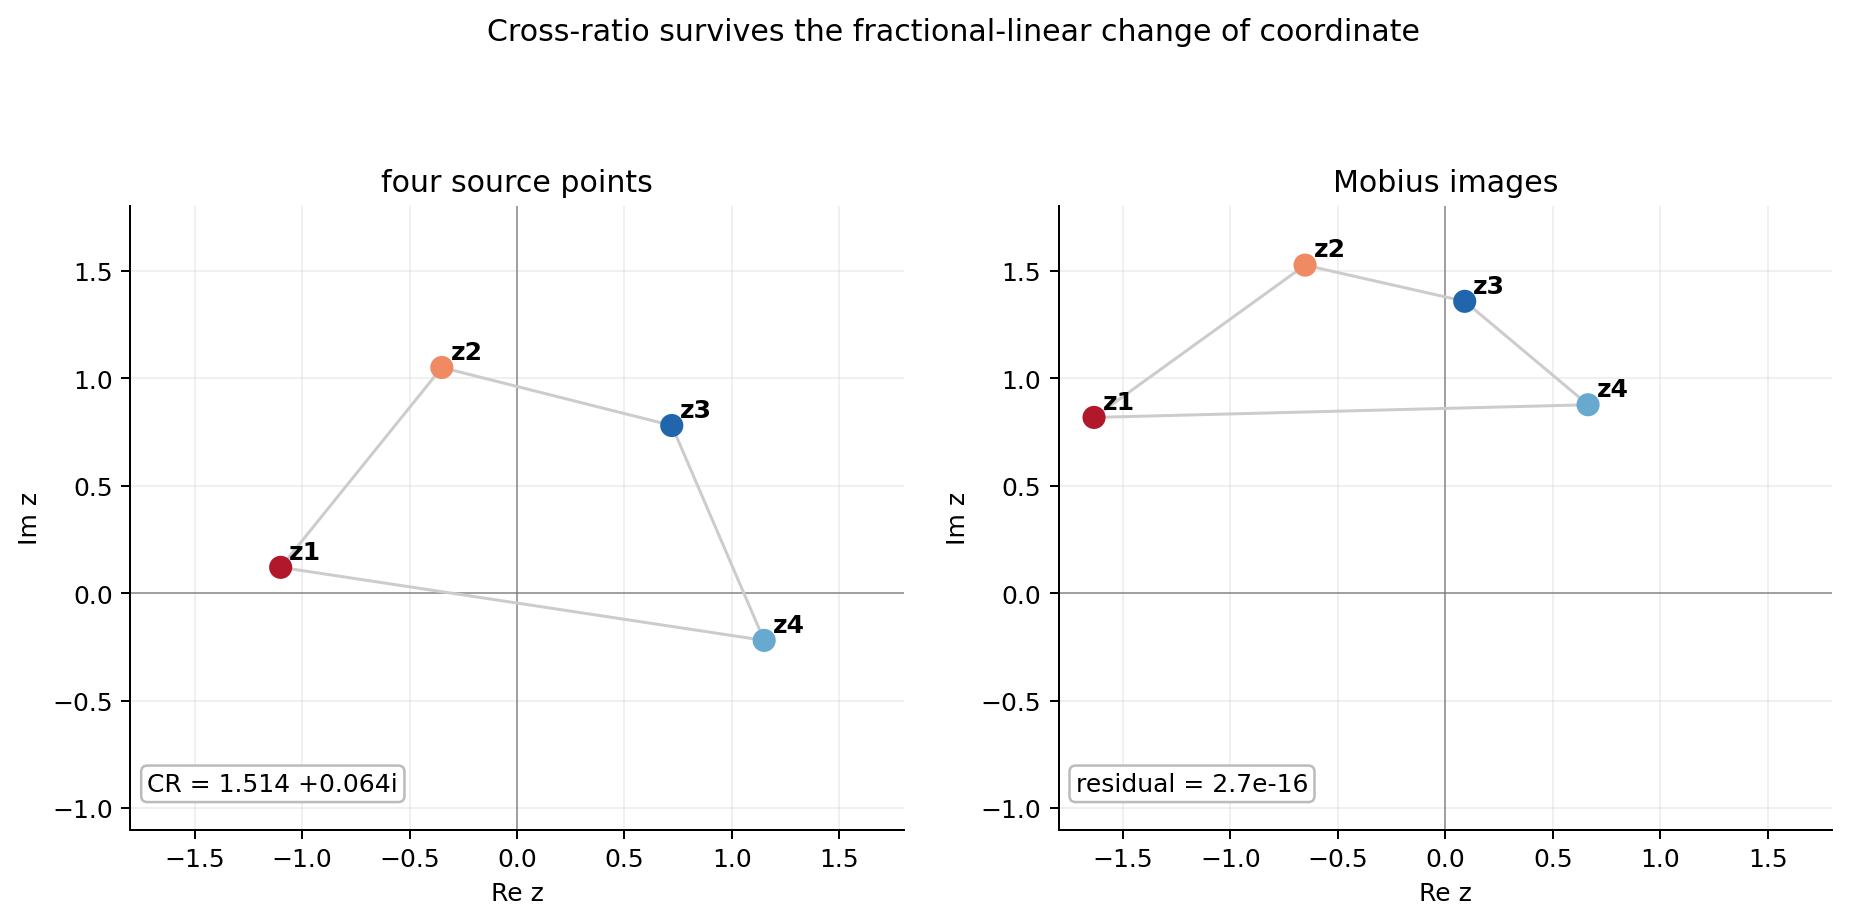

{'reciprocal_circle_line_coefficient_swap': True,
 'cross_ratio_mobius_invariance': True,
 'mobius_inverse_composition': True}

In [8]:
z1, z2, z3, z4, aa, bb, cc, dd = sp.symbols("z1 z2 z3 z4 aa bb cc dd")


def sym_cr(x1, x2, x3, x4):
    return ((x1 - x3) * (x2 - x4)) / ((x1 - x4) * (x2 - x3))


def sym_M(z):
    return (aa * z + bb) / (cc * z + dd)


cr_ratio = sp.factor(sp.together(sym_cr(sym_M(z1), sym_M(z2), sym_M(z3), sym_M(z4)) / sym_cr(z1, z2, z3, z4)))
symbolic_checks["cross_ratio_mobius_invariance"] = bool(cr_ratio == 1)

z = sp.symbols("z")
N_of_M = sp.simplify((dd * sym_M(z) - bb) / (-cc * sym_M(z) + aa))
symbolic_checks["mobius_inverse_composition"] = bool(sp.simplify(N_of_M - z) == 0)

points = np.array([-1.10 + 0.12j, -0.35 + 1.05j, 0.72 + 0.78j, 1.15 - 0.22j], dtype=np.complex128)
M_cross = (1.10 + 0.35j, -0.30 + 0.62j, 0.16 - 0.21j, 1.0 - 0.05j)
images = mobius_array(points, M_cross)
cr_before = cross_ratio(*points)
cr_after = cross_ratio(*images)
numeric_checks["cross_ratio_numeric_residual"] = float(abs(cr_before - cr_after))

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.3))
for ax, pts, title in [(axes[0], points, "four source points"), (axes[1], images, "Mobius images")]:
    format_complex_axes(ax, title=title, xlim=(-1.8, 1.8), ylim=(-1.1, 1.8))
    ax.plot(np.r_[pts.real, pts.real[0]], np.r_[pts.imag, pts.imag[0]], color="#cccccc", lw=1.2)
    ax.scatter(pts.real, pts.imag, s=68, color=["#b2182b", "#ef8a62", "#2166ac", "#67a9cf"], zorder=5)
    for label, point in zip(["z1", "z2", "z3", "z4"], pts):
        ax.text(point.real + 0.04, point.imag + 0.04, label, weight="bold")
axes[0].text(-1.72, -0.92, f"CR = {cr_before.real:.3f} {cr_before.imag:+.3f}i", bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#bbbbbb"})
axes[1].text(-1.72, -0.92, f"residual = {abs(cr_before - cr_after):.1e}", bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#bbbbbb"})
fig.suptitle("Cross-ratio survives the fractional-linear change of coordinate", y=1.02)
path = save_figure(fig, "cross-ratio-invariance.png")
display_artifact(path, width=960)

symbolic_path = write_json(CHECK_DIR / "symbolic-identities.json", symbolic_checks)
symbolic_checks


## Conformality, Orientation, And Conjugation

A holomorphic Mobius map has local derivative $(ad-bc)/(cz+d)^2$, which acts on tangent vectors by complex multiplication. That preserves angles and orientation. A conjugate-Mobius map first reflects the plane by $z\mapsto\bar z$; it still preserves the size of angles, but reverses orientation. The figure uses a tiny oriented triangle as a local frame detector.

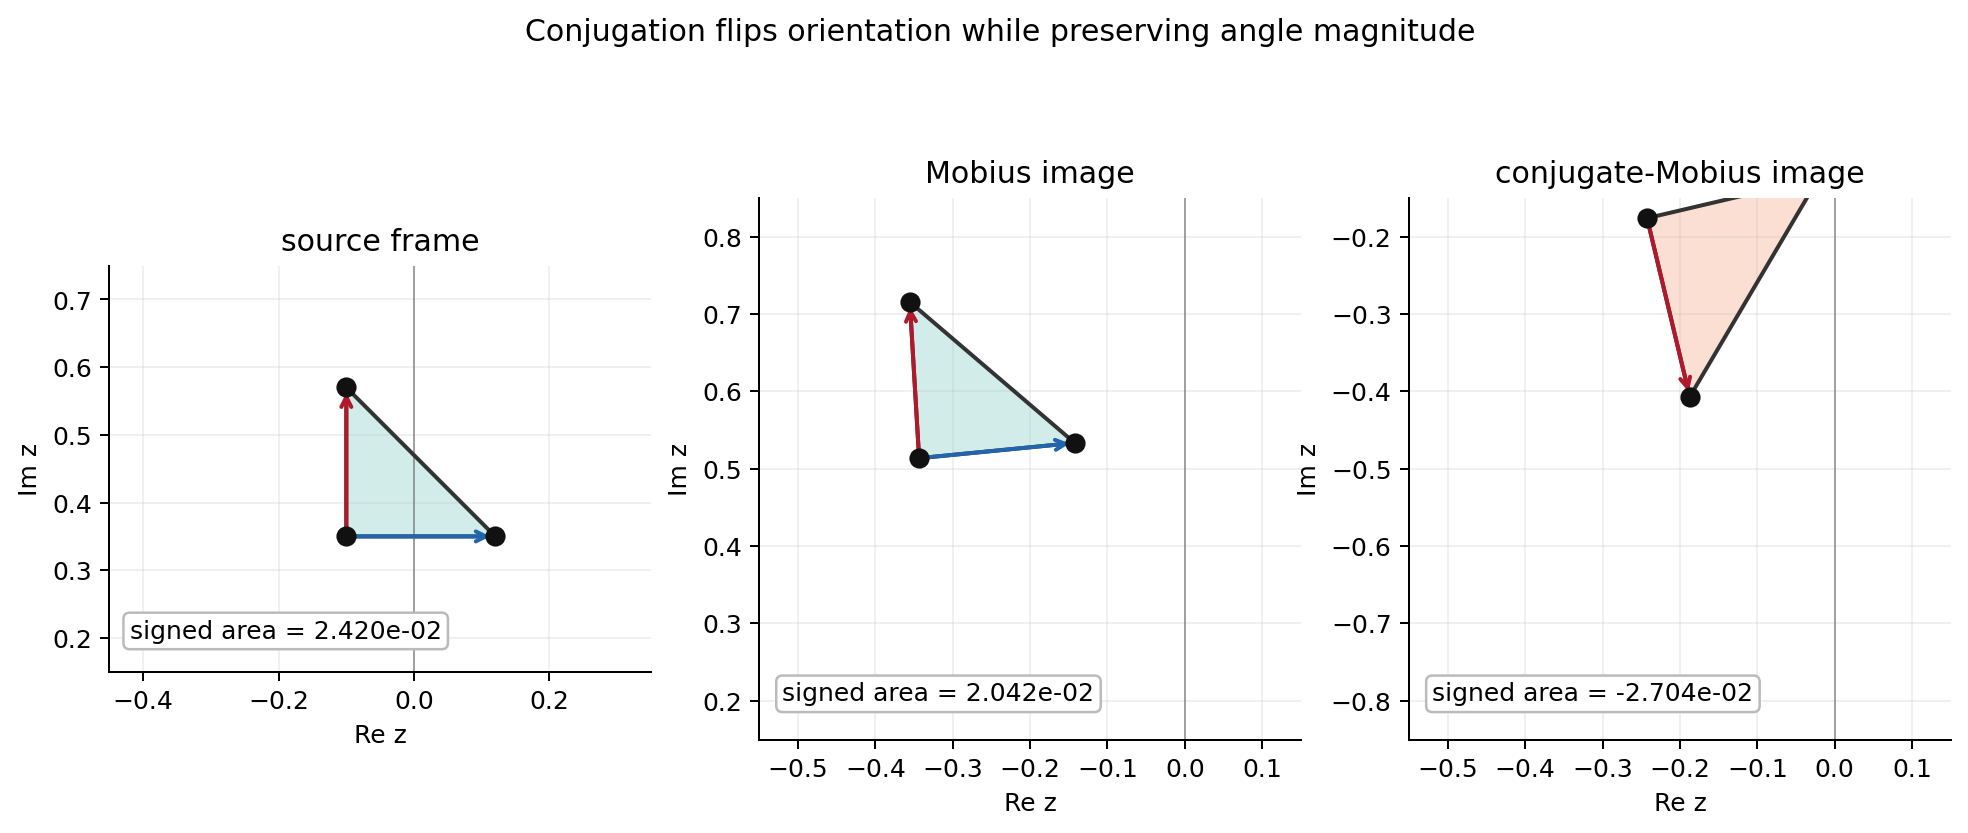

In [9]:
J = sp.Matrix([[sp.diff(x_expr, u), sp.diff(x_expr, v)], [sp.diff(y_expr, u), sp.diff(y_expr, v)]])
metric_pullback = sp.simplify(J.T * J)
target_metric = sp.eye(2) / den**2
symbolic_checks["reciprocal_conformal_metric"] = bool(all(sp.simplify(metric_pullback[i, j] - target_metric[i, j]) == 0 for i in range(2) for j in range(2)))
write_json(CHECK_DIR / "symbolic-identities.json", symbolic_checks)

M_orient = (0.95 + 0.25j, -0.22 + 0.18j, 0.10 - 0.08j, 1.0 + 0.06j)
z0 = -0.10 + 0.35j
eps_vis = 0.22
local_triangle = np.array([z0, z0 + eps_vis, z0 + 1j * eps_vis], dtype=np.complex128)
direct_triangle = mobius_array(local_triangle, M_orient)
conj_triangle = mobius_array(np.conj(local_triangle), M_orient)
area_source = signed_area(local_triangle)
area_direct = signed_area(direct_triangle)
area_conj = signed_area(conj_triangle)

D0 = mobius_derivative(z0, M_orient)
numeric_checks["orientation_direct_area_positive"] = bool(area_direct * area_source > 0)
numeric_checks["orientation_conjugate_area_negative"] = bool(area_conj * area_source < 0)
numeric_checks["orientation_direct_angle_residual"] = abs(angle_between(D0, 1j * D0) - np.pi / 2)
numeric_checks["orientation_conjugate_angle_residual"] = abs(angle_between(D0, -1j * D0) - np.pi / 2)

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.6))
panels = [
    (local_triangle, "source frame", area_source, (-0.45, 0.35), (0.15, 0.75)),
    (direct_triangle, "Mobius image", area_direct, (-0.55, 0.15), (0.15, 0.85)),
    (conj_triangle, "conjugate-Mobius image", area_conj, (-0.55, 0.15), (-0.85, -0.15)),
]
for ax, (pts, title, area, xlim, ylim) in zip(axes, panels):
    format_complex_axes(ax, title=title, xlim=xlim, ylim=ylim)
    closed = np.r_[pts, pts[0]]
    ax.plot(closed.real, closed.imag, color="#333333", lw=1.6)
    ax.fill(closed.real, closed.imag, color="#80cdc1" if area > 0 else "#f4a582", alpha=0.35)
    ax.scatter(pts.real, pts.imag, s=50, color="#111111", zorder=4)
    ax.annotate("", xy=(pts[1].real, pts[1].imag), xytext=(pts[0].real, pts[0].imag), arrowprops={"arrowstyle": "->", "lw": 1.6, "color": "#2166ac"})
    ax.annotate("", xy=(pts[2].real, pts[2].imag), xytext=(pts[0].real, pts[0].imag), arrowprops={"arrowstyle": "->", "lw": 1.6, "color": "#b2182b"})
    ax.text(xlim[0] + 0.03, ylim[0] + 0.05, f"signed area = {area:.3e}", bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#bbbbbb"})
fig.suptitle("Conjugation flips orientation while preserving angle magnitude", y=1.04)
path = save_figure(fig, "orientation-conjugation.png")
display_artifact(path, width=980)


## Link To Hyperbolic Models

The same fractional-linear formulas become isometries when their coefficients are restricted to preserve the disk or upper half-plane. In the Poincare disk, the map

$$\phi_a(z)=\frac{z-a}{1-\bar a z}$$

is a Mobius transformation that moves $a$ to the origin, preserves the unit boundary, and carries disk geodesics to disk geodesics. This section checks the boundary and distance invariants numerically.

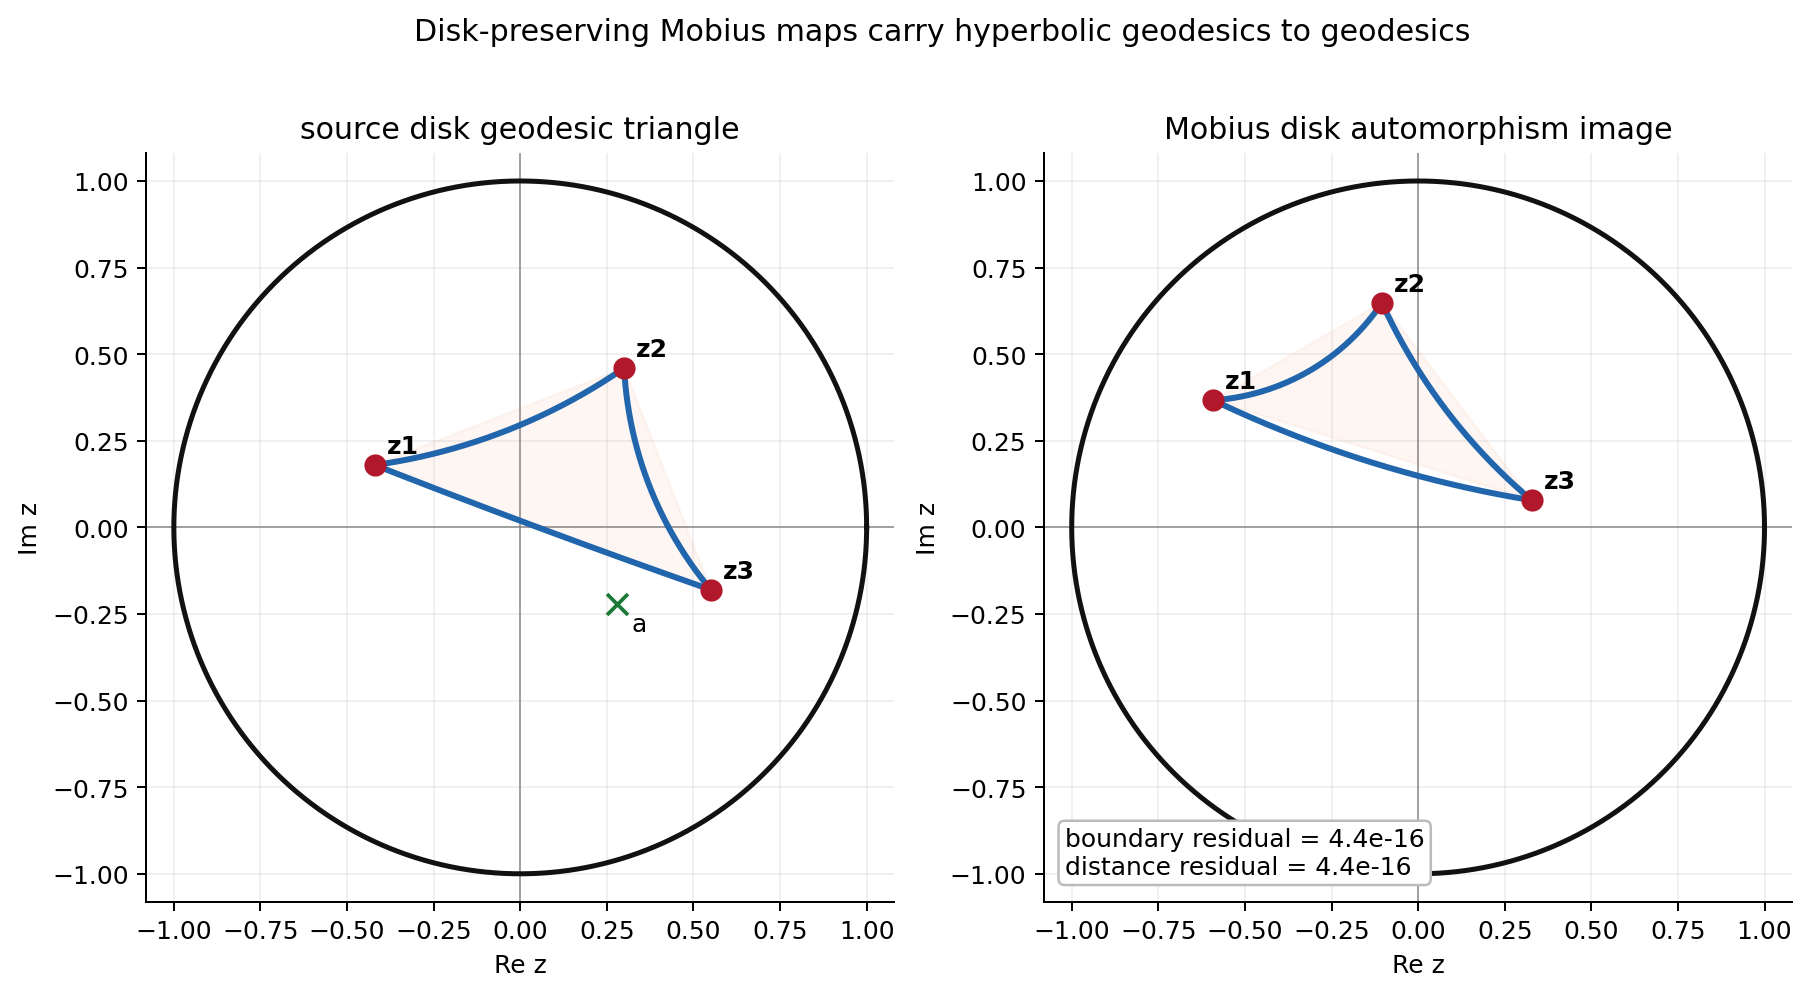

In [10]:
disk_points = np.array([-0.42 + 0.18j, 0.30 + 0.46j, 0.55 - 0.18j], dtype=np.complex128)
a_disk = 0.28 - 0.22j
moved_points = disk_auto(disk_points, a_disk)

boundary_samples = np.exp(1j * np.linspace(0, 2 * np.pi, 500, endpoint=False))
boundary_images = disk_auto(boundary_samples, a_disk)
boundary_residual = np.max(np.abs(np.abs(boundary_images) - 1))
distance_residuals = []
for i in range(len(disk_points)):
    for j in range(i + 1, len(disk_points)):
        distance_residuals.append(abs(hyp_dist_disk(disk_points[i], disk_points[j]) - hyp_dist_disk(moved_points[i], moved_points[j])))

numeric_checks["hyperbolic_boundary_residual"] = float(boundary_residual)
numeric_checks["hyperbolic_distance_max_residual"] = float(max(distance_residuals))

fig, axes = plt.subplots(1, 2, figsize=(11.8, 5.4))
for ax, pts, title in [(axes[0], disk_points, "source disk geodesic triangle"), (axes[1], moved_points, "Mobius disk automorphism image")]:
    format_complex_axes(ax, title=title, xlim=(-1.08, 1.08), ylim=(-1.08, 1.08))
    plot_complex_curve(ax, circle_points(0, 1, n=720), color="#111111", lw=2.0)
    for i, j in [(0, 1), (1, 2), (2, 0)]:
        geo = disk_geodesic_points(pts[i], pts[j])
        plot_complex_curve(ax, geo, color="#2166ac", lw=2.4)
    ax.fill(pts.real, pts.imag, color="#fddbc7", alpha=0.23)
    ax.scatter(pts.real, pts.imag, s=62, color="#b2182b", zorder=5)
    for label, point in zip(["z1", "z2", "z3"], pts):
        ax.text(point.real + 0.035, point.imag + 0.035, label, weight="bold")
axes[0].scatter([a_disk.real], [a_disk.imag], s=70, marker="x", color="#1b7837", zorder=6)
axes[0].text(a_disk.real + 0.04, a_disk.imag - 0.08, "a")
axes[1].text(-1.02, -1.0, f"boundary residual = {boundary_residual:.1e}\ndistance residual = {max(distance_residuals):.1e}", bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#bbbbbb"})
fig.suptitle("Disk-preserving Mobius maps carry hyperbolic geodesics to geodesics", y=1.02)
path = save_figure(fig, "hyperbolic-disk-mobius-link.png")
display_artifact(path, width=940)


## Applied Lab: Classify Images Of Circles And Lines

Edit the source curves or the pole in this cell and rerun it. The lab asks whether the transformed object is a line or circle after applying $w=1/(z-p)$. The inspection rule is simple: a source Circle through the pole should become a line; a source Circle missing the pole should become a circle. The residual column checks whether the sampled image really lies on one fitted generalized Circle.

In [11]:
lab_pole = pole
lab_M = M_pole
lab_specs = [
    {"name": "editable circle through pole", "points": circle_points(lab_pole + 0.62 - 0.08j, abs(0.62 - 0.08j), n=900), "through_pole": True},
    {"name": "editable circle missing pole", "points": circle_points(-0.78 - 0.52j, 0.38, n=900), "through_pole": False},
    {"name": "editable slanted line missing pole", "points": line_points(-1.25 + 0.78j, 1 + 0.28j, -2.0, 2.0, n=900), "through_pole": False},
]
lab_rows = []
for spec in lab_specs:
    image = mobius_array(spec["points"], lab_M)
    finite = image[np.isfinite(image.real) & np.isfinite(image.imag) & (np.abs(image) < 30)]
    coeff, rms = fit_generalized_circle(finite)
    classification = classify_generalized_circle(coeff)
    expected = "line" if spec["through_pole"] else "circle"
    lab_rows.append({
        "source": spec["name"],
        "pole_on_source_circle": spec["through_pole"],
        "expected_image_type": expected,
        "fitted_image_type": classification,
        "matches_rule": classification == expected,
        "fit_rms": rms,
        "leading_coefficient_abs": abs(coeff[0]),
    })
lab_table = pd.DataFrame(lab_rows)
lab_path = TABLE_DIR / "applied-lab-circle-classifier.csv"
lab_table.to_csv(lab_path, index=False)
remember(lab_path)
numeric_checks["lab_max_fit_residual"] = float(lab_table["fit_rms"].max())
numeric_checks["lab_all_classifications_match"] = bool(lab_table["matches_rule"].all())
lab_table


,source,pole_on_source_circle,expected_image_type,fitted_image_type,matches_rule,fit_rms,leading_coefficient_abs
0,editable circle through pole,True,line,line,True,8.626661e-15,0.000000
1,editable circle missing pole,False,circle,circle,True,4.750194e-16,0.734938
2,editable slanted line missing pole,False,circle,circle,True,3.675770e-16,0.897388


## Final Sanity Checks

The final cell asserts the core identities and artifact contract for this appendix pass: exact algebraic identities, numeric residuals, nonblank visual artifacts, generated metadata, and the applied lab classification rule.

In [12]:
tolerances = {
    "stereographic_unit_norm_residual": 1e-12,
    "stereographic_large_radius_to_north_pole_residual": 1e-9,
    "mobius_matrix_scale_residual": 1e-12,
    "mobius_inverse_residual": 1e-12,
    "mobius_conformal_angle_residual": 1e-12,
    "mobius_conformal_scale_residual": 1e-12,
    "circle_line_max_fit_residual": 1e-10,
    "circle_through_pole_image_leading_abs": 1e-10,
    "inversion_distance_product_residual": 1e-12,
    "inversion_setwise_circle_residual": 1e-12,
    "inversion_orthogonality_residual": 1e-12,
    "cross_ratio_numeric_residual": 1e-12,
    "orientation_direct_angle_residual": 1e-12,
    "orientation_conjugate_angle_residual": 1e-12,
    "hyperbolic_boundary_residual": 1e-12,
    "hyperbolic_distance_max_residual": 1e-12,
    "lab_max_fit_residual": 1e-10,
}

for key, tol in tolerances.items():
    assert key in numeric_checks, f"missing numeric check: {key}"
    assert float(numeric_checks[key]) <= tol, f"{key}={numeric_checks[key]} exceeds {tol}"

for key in [
    "inversion_center_image_inside_fixed_circle",
    "orientation_direct_area_positive",
    "orientation_conjugate_area_negative",
    "lab_all_classifications_match",
]:
    assert numeric_checks.get(key) is True, f"expected true check: {key}"

for key in [
    "reciprocal_circle_line_coefficient_swap",
    "cross_ratio_mobius_invariance",
    "mobius_inverse_composition",
    "reciprocal_conformal_metric",
]:
    assert symbolic_checks.get(key) is True, f"missing symbolic identity: {key}"

artifact_records = []
for path in sorted(set(artifact_paths), key=lambda p: p.as_posix()):
    suffix = path.suffix.lower()
    min_bytes = 100
    if suffix == ".png":
        min_bytes = 2500
    elif suffix == ".html":
        min_bytes = 3500
    elif suffix == ".csv":
        min_bytes = 80
    checked = assert_artifact(path, min_bytes=min_bytes)
    record = {"path": book_rel(checked), "bytes": checked.stat().st_size}
    if suffix == ".png":
        image = Image.open(checked).convert("L")
        arr = np.asarray(image, dtype=float)
        record["pixel_std"] = float(arr.std())
        assert record["pixel_std"] > 1.0, f"blank-looking image: {checked}"
    artifact_records.append(record)

residual_values = [float(value) for key, value in numeric_checks.items() if isinstance(value, (int, float, np.floating)) and "residual" in key]
final_sanity = {
    "unit": UNIT,
    "source_span_used": source_span,
    "storyboard_items_implemented": [item["concept"] for item in storyboard["visual_sequence"]],
    "libraries_used": {
        "NumPy": "complex-coordinate arrays, Mobius evaluation, circle fitting, and metric residuals",
        "Matplotlib": "durable 2D diagrams for generalized Circles, inversion, cross-ratio, orientation, and disk geodesics",
        "Plotly": "interactive Riemann-sphere and Mobius grid artifacts",
        "SymPy": "exact cross-ratio, inverse-composition, reciprocal Circle, and conformality identities",
        "pandas": "editable applied lab classification table",
        "Pillow": "nonblank visual artifact checks",
    },
    "artifact_count": len(artifact_records),
    "artifacts": artifact_records,
    "numeric_checks": numeric_checks,
    "symbolic_checks": symbolic_checks,
    "tolerances": tolerances,
    "max_recorded_residual": max(residual_values),
    "known_gaps": [
        "Plotly HTML artifacts load Plotly from a CDN to keep artifacts small; the core proof visuals are static PNGs.",
        "The notebook samples representative Mobius and conjugate-Mobius maps rather than classifying every possible coefficient normalization.",
    ],
}

final_path = write_json(CHECK_DIR / "final-sanity.json", final_sanity)
notebook_sanity = {
    "unit": UNIT,
    "checks_passed": True,
    "source_span": source_span,
    "artifact_count": len(artifact_records) + 1,
    "artifact_names": [Path(record["path"]).name for record in artifact_records] + [final_path.name],
    "max_recorded_residual": final_sanity["max_recorded_residual"],
    "has_interactive_artifacts": any(record["path"].endswith(".html") for record in artifact_records),
    "has_applied_lab_table": any(record["path"].endswith(".csv") for record in artifact_records),
    "has_symbolic_checks": all(symbolic_checks.values()),
}
notebook_sanity_path = write_json(CHECK_DIR / "notebook-sanity.json", notebook_sanity)
assert_artifact(final_path, min_bytes=1000)
assert_artifact(notebook_sanity_path, min_bytes=300)
final_sanity


{'unit': 'appendix-a2',
 'source_span_used': {'unit': 'Appendix A2',
  'pdf_pages': '390-398',
  'printed_pages_seen_in_extraction': 'Appendix 2 title page through printed page 399 in this PDF copy',
  'source_map_note': 'AGENTS.md maps Appendices A0-A2 to PDF pages 379-398; this pass uses the assigned Appendix A2 span only.',
  'orientation_only': True},
 'storyboard_items_implemented': ['extended complex plane',
  'Mobius grid action',
  'Circle preservation',
  'inversion',
  'cross-ratio',
  'orientation/conjugation',
  'hyperbolic disk link'],
 'libraries_used': {'NumPy': 'complex-coordinate arrays, Mobius evaluation, circle fitting, and metric residuals',
  'Matplotlib': 'durable 2D diagrams for generalized Circles, inversion, cross-ratio, orientation, and disk geodesics',
  'Plotly': 'interactive Riemann-sphere and Mobius grid artifacts',
  'SymPy': 'exact cross-ratio, inverse-composition, reciprocal Circle, and conformality identities',
  'pandas': 'editable applied lab classif

## Takeaways

- A Mobius transformation is a projective coordinate change on $C_\infty$, not just a rational function on an ordinary punctured plane.
- Lines and circles are one generalized Circle class because reciprocal action swaps the quadratic and constant parts of their real equation.
- Holomorphic Mobius maps preserve oriented angles; adding conjugation preserves angle magnitudes but reverses orientation.
- Inversions are conjugate-Mobius maps with a metric definition, and orthogonal circles are exactly the setwise fixed Circles.
- Cross-ratio is the algebraic invariant that later reappears in hyperbolic distance formulas and model changes.
- The same formulas organize stereographic sphere charts and the disk/half-plane transformations used in hyperbolic geometry.